# 1 - Preliminaries

In [169]:
import copy
import itertools
from collections import defaultdict
import math
from operator import itemgetter
import numpy as np
import pandas as pd
import seaborn as sns

#### Our dataset format
An event is a list of strings.

A sequence is a list of events.

A dataset is a list of sequences.

Thus, a dataset is a list of lists of lists of strings.

In [170]:
dataset =  [
    [["a"], ["a", "b", "c"], ["a", "c"], ["c"]],
    [["a"], ["c"], ["b", "c"]],
    [["a", "b"], ["d"], ["c"], ["b"], ["c"]],
    [["a"], ["c"], ["b"], ["c"]]
]

# 2- Foundations
### Subsequences

In [171]:
"""
This is a simple recursive method that checks if subsequence is a subSequence of mainSequence
"""
def isSubsequence(mainSequence, subSequence):
    subSequenceClone = list(subSequence) # clone the sequence, because we will alter it
    return isSubsequenceRecursive(mainSequence, subSequenceClone) #start recursion

"""
Function for the recursive call of isSubsequence, not intended for external calls
"""
def isSubsequenceRecursive(mainSequence, subSequenceClone, start=0):
    # Check if empty: End of recursion, all itemsets have been found
    if (not subSequenceClone):
        return True
    # retrieves element of the subsequence and removes is from subsequence 
    firstElem = set(subSequenceClone.pop(0))
    # Search for the first itemset...
    for i in range(start, len(mainSequence)):
        if (set(mainSequence[i]).issuperset(firstElem)):
            # and recurse
            return isSubsequenceRecursive(mainSequence, subSequenceClone, i + 1)
    return False

In [172]:
aSequence = [["a"], ["b", "c"], ["d"], ["a", "e"]]

In [173]:
isSubsequence(aSequence, [["a"], ["d"], ["e"]])

True

In [174]:
isSubsequence(aSequence, [["a"], ["b", "c"], ["e"]])

True

In [175]:
isSubsequence(aSequence, [["a"], ["b", "d"]])

False

### Length of an itemset

In [176]:
"""
Computes the length of the sequence (sum of the length of the contained itemsets)
"""
def sequenceLength(sequence):
    return sum(len(i) for i in sequence)

In [177]:
print(sequenceLength ([["a"], ["b", "c"], ["a"], ["b","c","d"]]))

7


### Support of a sequence

In [178]:
"""
Computes the support of a sequence in a dataset
"""
def countSupport (dataset, candidateSequence):
    return sum(1 for seq in dataset if isSubsequence(seq, candidateSequence)) 

In [179]:
dataset

[[['a'], ['a', 'b', 'c'], ['a', 'c'], ['c']],
 [['a'], ['c'], ['b', 'c']],
 [['a', 'b'], ['d'], ['c'], ['b'], ['c']],
 [['a'], ['c'], ['b'], ['c']]]

In [180]:
countSupport(dataset, [["b"]])

4

In [181]:
countSupport(dataset, [["a"], ["b", "c"]])

2

# 3- PrefixSpan algorithm

### Project a sequence

In [182]:
"""
Projects a sequence according to a given prefix, as done in PrefixSpan

Args:
    sequence: the sequence the projection is built from
    prefix: the prefix that is searched for in the sequence
    newEvent: if set to True, the first itemset is ignored
Returns:
    If the sequence does not contain the prefix, then None.
    Otherwise, a new sequence starting from the position of the prefix, including the itemset that includes the prefix
"""
def projectSequence(sequence, prefix, newEvent):
    result = None
    for i, itemset in enumerate(sequence):
        if result is None:
            if (not newEvent) or i > 0:
                if (all(x in itemset for x in prefix)):
                    result = [list(itemset)]
        else:
            result.append(copy.copy(itemset))
    return result

In [183]:
seq = [["a"], ["b", "c"], ["a", "c"], ["c"]]
projectSequence(seq, ["b"], False)

[['b', 'c'], ['a', 'c'], ['c']]

In [184]:
projectSequence(seq, ["a", "c"], False)

[['a', 'c'], ['c']]

In [185]:
projectSequence(seq, ["a"], False)

[['a'], ['b', 'c'], ['a', 'c'], ['c']]

In [186]:
projectSequence(seq, ["a"], True)

[['a', 'c'], ['c']]

### Project a dataset

In [187]:
"""
Projects a dataset according to a given prefix, as done in PrefixSpan

Args:
    dataset: the dataset the projection is built from
    prefix: the prefix that is searched for in the sequence
    newEvent: if set to True, the first itemset is ignored
Returns:
    A (potentially empty) list of sequences
"""
def projectDatabase(dataset, prefix, newEvent):
    projectedDB = []
    for sequence in dataset:
        seqProjected = projectSequence(sequence, prefix, newEvent)
        if not seqProjected is None:
            projectedDB.append(seqProjected)
    return projectedDB

In [188]:
datasetProject = [
            [["a"], ["a", "b", "c"], ["a", "c"], ["d"], ["c", "f"]],
            [["a", "d"], ["c"], ["b", "c"], ["a", "e"]],
            [["e", "f"], ["a", "b"], ["d", "f"], ["d"], ["b"]],
            [["e"], ["g"], ["a", "f"], ["c"], ["b"], ["c"]]
        ]

In [189]:
projectDatabase(datasetProject, ["c"], False)

[[['a', 'b', 'c'], ['a', 'c'], ['d'], ['c', 'f']],
 [['c'], ['b', 'c'], ['a', 'e']],
 [['c'], ['b'], ['c']]]

### The main algorithm

#### Some more utility functions:

In [190]:
"""
Generates a list of all items that are contained in a dataset
"""
def generateItems(dataset):
    return sorted(set ([item for sublist1 in dataset for sublist2 in sublist1 for item in sublist2]))

"""
Computes a defaultdict that maps each item in the dataset to its support
"""
def generateItemSupports(dataset, ignoreFirstEvent=False, prefix=[]):
    result = defaultdict(int)
    for sequence in dataset:
        if ignoreFirstEvent:
            sequence = sequence[1:]
        cooccurringItems = set()
        for itemset in sequence:
            if all(x in itemset for x in prefix):
                for item in itemset:
                    if not item in prefix:
                        cooccurringItems.add(item)
        for item in cooccurringItems:
            result [item] += 1
    return sorted(result.items())

#### Finally, the algorithm:

In [191]:
"""
The PrefixSpan algorithm. Computes the frequent sequences in a seqeunce dataset for a given minFrequency

Args:
    dataset: A list of sequences, for which the frequent (sub-)sequences are computed
    minFrequency: The minimum support that makes a sequence frequent
Returns:
    A list of tuples (s, c), where s is a frequent sequence, and c is the count for that sequence
"""
def prefixSpan(dataset, minFrequency):
    result = []
    itemCounts = generateItemSupports(dataset)
    for item, count in itemCounts:
        if count >= minFrequency:
            newPrefix = [[item]]
            result.append((newPrefix, count))
            result.extend(prefixSpanInternal(projectDatabase(dataset, [item], False), minFrequency, newPrefix))
    return result

def prefixSpanInternal(dataset, minFrequency, prevPrefixes=[]):
    result = []
    
    # Add a new item to the last element (==same time)
    
        
    # Add a new event to the prefix
    itemCountSubsequentEvents = generateItemSupports(dataset, True)
    for item, count in itemCountSubsequentEvents:
        if count >= minFrequency:
            newPrefix = copy.deepcopy(prevPrefixes)
            newPrefix.append([item])
            result.append((newPrefix, count))
            result.extend(prefixSpanInternal(projectDatabase(dataset, [item], True), minFrequency, newPrefix))
    return result

In [192]:
prefixSpan(dataset, 2)

[([['a']], 4),
 ([['a'], ['b']], 4),
 ([['a'], ['b'], ['c']], 3),
 ([['a'], ['c']], 4),
 ([['a'], ['c'], ['b']], 3),
 ([['a'], ['c'], ['b'], ['c']], 2),
 ([['a'], ['c'], ['c']], 4),
 ([['b']], 4),
 ([['b'], ['c']], 3),
 ([['b'], ['c'], ['c']], 2),
 ([['c']], 4),
 ([['c'], ['b']], 3),
 ([['c'], ['b'], ['c']], 2),
 ([['c'], ['c']], 4)]

# 4- Practical work: analyzing YahooFinance data
Now we try to find some sequential patterns in a real world dataset.

First load the dataset.

Binôme : Yulin Chai, Lucas Pagano 

In [193]:
import csv

currentLineNumber=0
idSeq='1'
newTransaction=[]
yahooDataset=[]

for line in csv.reader((row for row in open("YahooFinance.data") if not row.endswith('0\n')), delimiter='\t'):
    currentLineNumber+=1
    if currentLineNumber==1:
        continue
    if line[1] != idSeq:
        yahooDataset.append(newTransaction)
        idSeq=line[1]
        newTransaction=[]
    newTransaction.append(line[2])

In [194]:
yahooDataset

[['Microsoft=3',
  'Citigroup=3',
  'Exxon_Mobil=-2',
  'HP=3',
  'Coca_Cola=-1',
  'General_Motors=3',
  'Intel=3',
  'Altria=-3',
  'American_Express=3',
  'AT&T=1',
  'Procter_&_Gamble=-2',
  'Verizon=3',
  'Morgan_Chase=3'],
 ['Microsoft=1',
  'Boeing=-1',
  'Citigroup=1',
  'Du_Pont=1',
  'Exxon_Mobil=-1',
  'HP=1',
  'Coca_Cola=-1',
  'General_Motors=2',
  'Intel=-1',
  'Altria=-2',
  'American_Express=-2',
  'AT&T=1',
  'Procter_&_Gamble=-2',
  'Verizon=1',
  'Morgan_Chase=1'],
 ['Microsoft=1',
  'Boeing=-2',
  'Citigroup=-2',
  'Du_Pont=-1',
  'HP=-3',
  'General_Motors=-3',
  'Intel=-3',
  'American_Express=-2',
  'AT&T=-2',
  'Procter_&_Gamble=2',
  'Morgan_Chase=-3'],
 ['HP=1',
  'Coca_Cola=1',
  'General_Motors=-1',
  'Altria=2',
  'American_Express=-3',
  'Procter_&_Gamble=1'],
 ['Microsoft=3',
  'Citigroup=-1',
  'Du_Pont=-2',
  'Exxon_Mobil=-1',
  'Coca_Cola=1',
  'General_Motors=2',
  'Altria=2',
  'American_Express=-2',
  'AT&T=2',
  'Procter_&_Gamble=-1',
  'Verizon=1

In [195]:
#Q1
#On extrait les fenêtres

windows = []
max_span = 4
for i, event in enumerate(yahooDataset):
    if i+max_span >= len(yahooDataset): break
    window = []
    window.append(event)
    for j, event2 in enumerate(yahooDataset[i+1:]):
        window.append(event2)
        if j == max_span-1: break
    windows.append(window)
    
print(len(windows))
len(yahooDataset)

1239


1243

In [196]:
#Q2 : On utilise prefixSpan
eventsFrequency = prefixSpan(windows, minFrequency=100)
eventsFrequency

[([['AT&T=-1']], 784),
 ([['AT&T=-1'], ['AT&T=-1']], 292),
 ([['AT&T=-1'], ['AT&T=1']], 278),
 ([['AT&T=-1'], ['Altria=-1']], 251),
 ([['AT&T=-1'], ['Altria=1']], 316),
 ([['AT&T=-1'], ['American_Express=-1']], 308),
 ([['AT&T=-1'], ['American_Express=1']], 305),
 ([['AT&T=-1'], ['American_Express=2']], 112),
 ([['AT&T=-1'], ['Boeing=-1']], 330),
 ([['AT&T=-1'], ['Boeing=-1'], ['Boeing=1']], 103),
 ([['AT&T=-1'], ['Boeing=1']], 351),
 ([['AT&T=-1'], ['Citigroup=-1']], 291),
 ([['AT&T=-1'], ['Citigroup=1']], 299),
 ([['AT&T=-1'], ['Coca_Cola=-1']], 269),
 ([['AT&T=-1'], ['Coca_Cola=1']], 275),
 ([['AT&T=-1'], ['Du_Pont=-1']], 287),
 ([['AT&T=-1'], ['Du_Pont=1']], 312),
 ([['AT&T=-1'], ['Exxon_Mobil=-1']], 286),
 ([['AT&T=-1'], ['Exxon_Mobil=1']], 367),
 ([['AT&T=-1'], ['Exxon_Mobil=1'], ['Boeing=1']], 111),
 ([['AT&T=-1'], ['Exxon_Mobil=1'], ['HP=-1']], 103),
 ([['AT&T=-1'], ['Exxon_Mobil=1'], ['Morgan_Chase=1']], 101),
 ([['AT&T=-1'], ['General_Motors=-1']], 312),
 ([['AT&T=-1'], ['Gen

In [197]:
#Q3 : On crée un dictionnaire pour répertorier les informations sur les évènements
dictEvents = {}
#L est le nombre total de fenêtres vu qu'on compte par fenêtre
L = len(windows)
for tupleEvent in eventsFrequency:
    eventName = " ".join(elem[0] for elem in tupleEvent[0])
    
    dictEvents[eventName] = {"count" : tupleEvent[1], "support" : tupleEvent[1]/L}

#Lift
#On ne le fait pas au premier passage car on a besoin que tous les évènements soient rajoutés
for tupleEvent in eventsFrequency:
    eventName = " ".join(elem[0] for elem in tupleEvent[0])
    freqNum = dictEvents[eventName]["support"]
    freqDenum = np.prod([dictEvents[elem[0]]["support"] for elem in tupleEvent[0]])
    dictEvents[eventName]["lift"] = freqNum/freqDenum

dictEvents

    

{'AT&T=-1': {'count': 784, 'support': 0.632768361581921, 'lift': 1.0},
 'AT&T=-1 AT&T=-1': {'count': 292,
  'support': 0.23567393058918482,
  'lift': 0.5886024052478133},
 'AT&T=-1 AT&T=1': {'count': 278,
  'support': 0.22437449556093625,
  'lift': 0.5676218161683277},
 'AT&T=-1 Altria=-1': {'count': 251,
  'support': 0.20258272800645682,
  'lift': 0.6246766029246343},
 'AT&T=-1 Altria=1': {'count': 316,
  'support': 0.255044390637611,
  'lift': 0.6203637976929902},
 'AT&T=-1 American_Express=-1': {'count': 308,
  'support': 0.24858757062146894,
  'lift': 0.6288759689922481},
 'AT&T=-1 American_Express=1': {'count': 305,
  'support': 0.24616626311541565,
  'lift': 0.6155925013683633},
 'AT&T=-1 American_Express=2': {'count': 112,
  'support': 0.0903954802259887,
  'lift': 0.657992565055762},
 'AT&T=-1 Boeing=-1': {'count': 330,
  'support': 0.26634382566585957,
  'lift': 0.6057117969138874},
 'AT&T=-1 Boeing=-1 Boeing=1': {'count': 103,
  'support': 0.08313155770782889,
  'lift': 0.249

In [198]:
#Q4 On laisse la j-measure de côté car il nous manque 
dictRules = {}
for tupleEvent in eventsFrequency:
    #On ne peut pas créer des règles à partir d'évènements uniques
    if len(tupleEvent[0])>1:
        eventName = " ".join(elem[0] for elem in tupleEvent[0])
        nameX = " ".join(elem[0] for elem in tupleEvent[0][:-1])
        nameY = tupleEvent[0][-1][0]
        ruleName = nameX + " ->" + nameY
        
        nx = dictEvents[nameX]["count"]
        ny = dictEvents[nameY]["count"]
        nxy = dictEvents[eventName]["count"]
        nxybar = nx - nxy
        
        confiance = nxy / nx
        rappel = nxy / ny
        j_measure = (nxy/L * math.log2(nxy*L/(nx*ny)) + (nxybar/L * math.log2(nxybar*L/(nx*(L-ny)))))
        
        dictRules[ruleName] = {"confiance" : confiance, "rappel" : rappel, "j-measure" : j_measure}
dictRules
        
        

{'AT&T=-1 ->AT&T=-1': {'confiance': 0.37244897959183676,
  'rappel': 0.37244897959183676,
  'j-measure': 0.1267663761483436},
 'AT&T=-1 ->AT&T=1': {'confiance': 0.35459183673469385,
  'rappel': 0.35917312661498707,
  'j-measure': 0.13611471569212996},
 'AT&T=-1 ->Altria=-1': {'confiance': 0.3201530612244898,
  'rappel': 0.3952755905511811,
  'j-measure': 0.06890232315365966},
 'AT&T=-1 ->Altria=1': {'confiance': 0.4030612244897959,
  'rappel': 0.39254658385093166,
  'j-measure': 0.11481590743201323},
 'AT&T=-1 ->American_Express=-1': {'confiance': 0.39285714285714285,
  'rappel': 0.3979328165374677,
  'j-measure': 0.10027133986620931},
 'AT&T=-1 ->American_Express=1': {'confiance': 0.38903061224489793,
  'rappel': 0.3895274584929757,
  'j-measure': 0.11039519363856809},
 'AT&T=-1 ->American_Express=2': {'confiance': 0.14285714285714285,
  'rappel': 0.4163568773234201,
  'j-measure': 0.016316914793614093},
 'AT&T=-1 ->Boeing=-1': {'confiance': 0.42091836734693877,
  'rappel': 0.38327526

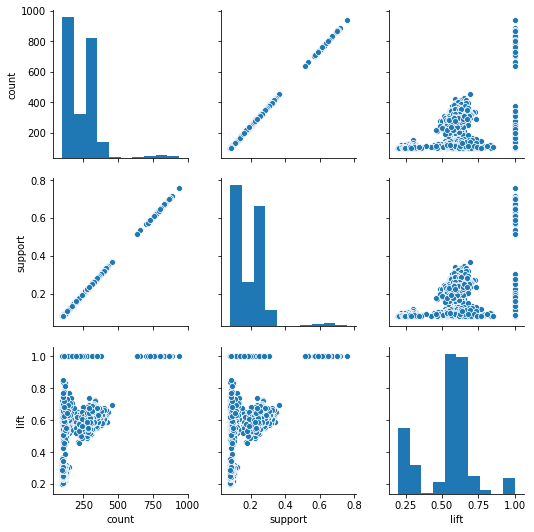

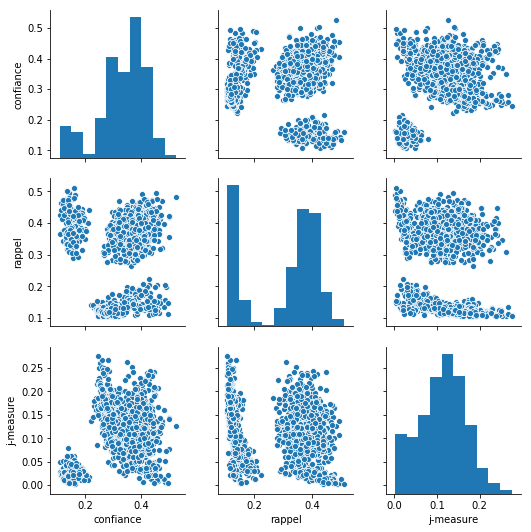

In [199]:
#Q5 stats 1D et 2D
df_episodes = pd.DataFrame.from_dict(dictEvents, orient="index")
df_rules = pd.DataFrame.from_dict(dictRules,  orient="index")
sns.pairplot(df_episodes)
sns.pairplot(df_rules)

#Il est normal que count et support aient une relation linéaire pour les épisodes : 
#la seule différence est la division par L

#On remarque que des clusters semblent apparaître dans les règles

In [200]:
#Poursuite de l'analyse
#Évènements qui arrivent sur la même entreprise
def sameCompany(string, rules=False):
    """
    Fonction qui renvoie vrai si tous les évènements arrivent sur la même entreprise, et faux sinon
    """
    if rules:
        string = string.replace("->", "")
    companies = string.split(" ")
    if len(companies) > 1:
        withoutVariation = []
        for company in companies:
            #on prend ce qu'il y a avant le =
            withoutVariation.append(company.split("=")[0])
        #return True if all elems are equal, false if not
        bool = withoutVariation.count(withoutVariation[0]) == len(withoutVariation)
    else: 
        bool = False
    return int(bool)
    


episodes_list = df_episodes.index.to_list()
rules_list = df_rules.index.to_list()
df_episodes["same"] =  [sameCompany(episode) for episode in episodes_list]
df_rules["same"] =  [sameCompany(rule, True) for rule in rules_list]

#taille de l'évènement
df_episodes["length"] = [len(episode.split(" ")) for episode in episodes_list]
df_rules["length"] = [len(rule.split(" ")) for rule in rules_list]
df_rules.head(50)

,confiance,rappel,j-measure,same,length
AT&T=-1 ->AT&T=-1,0.372449,0.372449,0.126766,1,2
AT&T=-1 ->AT&T=1,0.354592,0.359173,0.136115,1,2
AT&T=-1 ->Altria=-1,0.320153,0.395276,0.068902,0,2
AT&T=-1 ->Altria=1,0.403061,0.392547,0.114816,0,2
AT&T=-1 ->American_Express=-1,0.392857,0.397933,0.100271,0,2
AT&T=-1 ->American_Express=1,0.389031,0.389527,0.110395,0,2
AT&T=-1 ->American_Express=2,0.142857,0.416357,0.016317,0,2
AT&T=-1 ->Boeing=-1,0.420918,0.383275,0.146135,0,2
AT&T=-1 ->Boeing=1,0.447704,0.373802,0.200622,0,2
AT&T=-1 ->Citigroup=-1,0.371173,0.387483,0.102388,0,2


/home/lucas/Software/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
/home/lucas/Software/anaconda3/lib/python3.6/site-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
/home/lucas/.local/lib/python3.6/site-packages/numpy/core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


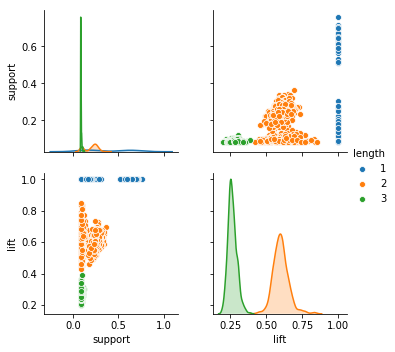

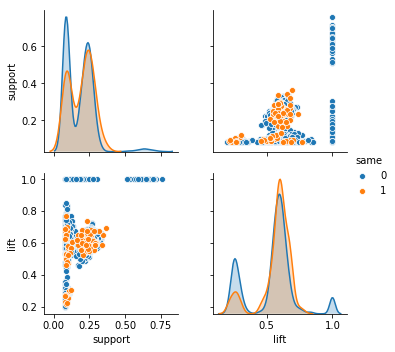

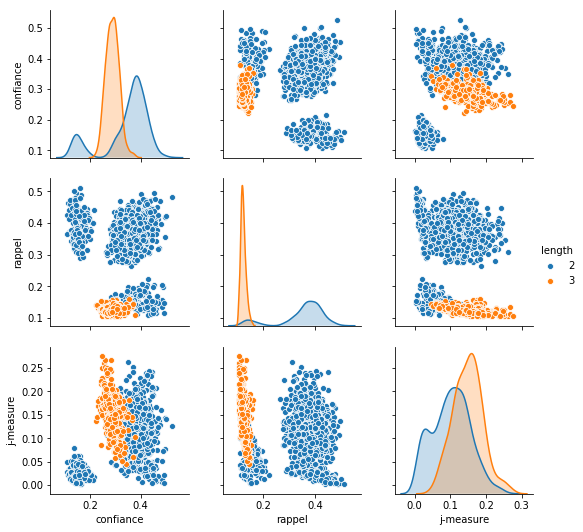

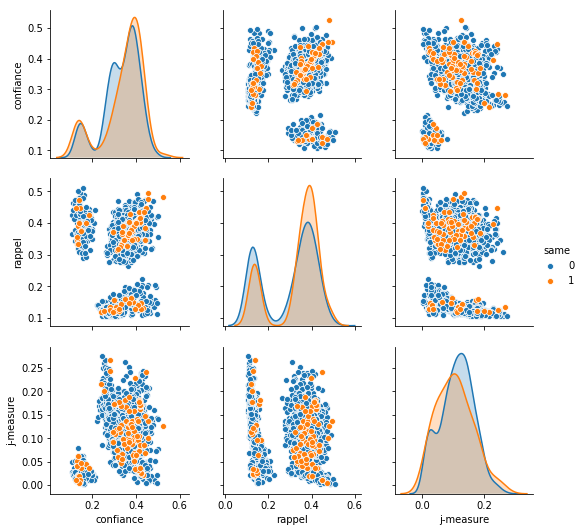

In [201]:
# On affiche les évènements et les règles en fonction de leur taille et de s'ils arrivent sur la même entreprise
sns.pairplot(df_episodes, hue="length", vars=[i for i in df_episodes.columns if i not in ["same", "count", "length"]])
sns.pairplot(df_episodes, hue="same", vars=[i for i in df_episodes.columns if i not in ["same", "count", "length"]])

sns.pairplot(df_rules, hue="length", vars=[i for i in df_rules.columns if i not in ["same", "length"]])
sns.pairplot(df_rules, hue="same", vars=[i for i in df_rules.columns if i not in ["same", "length"]])

On remarque que la taille est discriminante pour le lift des épisodes, et surtout pour les règles.

Question 6 : Intuitivement, les meilleurs épisodes de taille 2 sont ceux qui s'appliquent sur la même entreprise. En effet une entreprise a plus de chances d'influencer son propre état que celui des autres entreprises. On le vérifie.

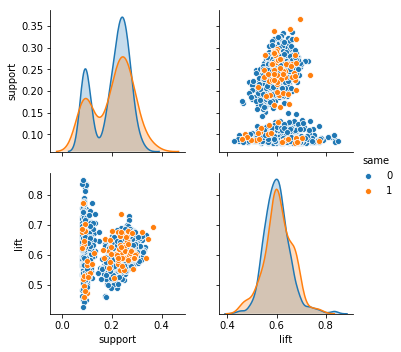

In [202]:
df_episodes_2 = df_episodes[df_episodes["length"] == 2]
sns.pairplot(df_episodes_2, hue="same", vars=[i for i in df_episodes_2.columns if i not in ["same", "count", "length"]])

Notre intuition s'avère fausse : on remarque en effet que les épisodes qui concernent la même entreprise sont répartis de façons homogène dans les données.

In [203]:
best_df_episodes_2 = df_episodes_2[df_episodes_2["support"] > 0.22]
best_df_episodes_2

,count,support,lift,same,length
AT&T=-1 AT&T=-1,292,0.235674,0.588602,1,2
AT&T=-1 AT&T=1,278,0.224374,0.567622,1,2
AT&T=-1 Altria=1,316,0.255044,0.620364,0,2
AT&T=-1 American_Express=-1,308,0.248588,0.628876,0,2
AT&T=-1 American_Express=1,305,0.246166,0.615593,0,2
AT&T=-1 Boeing=-1,330,0.266344,0.605712,0,2
AT&T=-1 Boeing=1,351,0.283293,0.590741,0,2
AT&T=-1 Citigroup=-1,291,0.234867,0.612362,0,2
AT&T=-1 Citigroup=1,299,0.241324,0.644648,0,2
AT&T=-1 Coca_Cola=1,275,0.221953,0.601104,0,2


On affiche les meilleurs épisodes de taille 2 au sens du support pour tenter de comprendre. Avec cet affichage, on remarque que beaucoup de lignes présentent Boeing et Intel. On peut supposer que ces entreprises influent beaucoup sur le marché grâce à leur taille, et que c'est pour cela qu'elles sont beaucoup représentées. Il faudrait cependant mener une étude plus poussée.